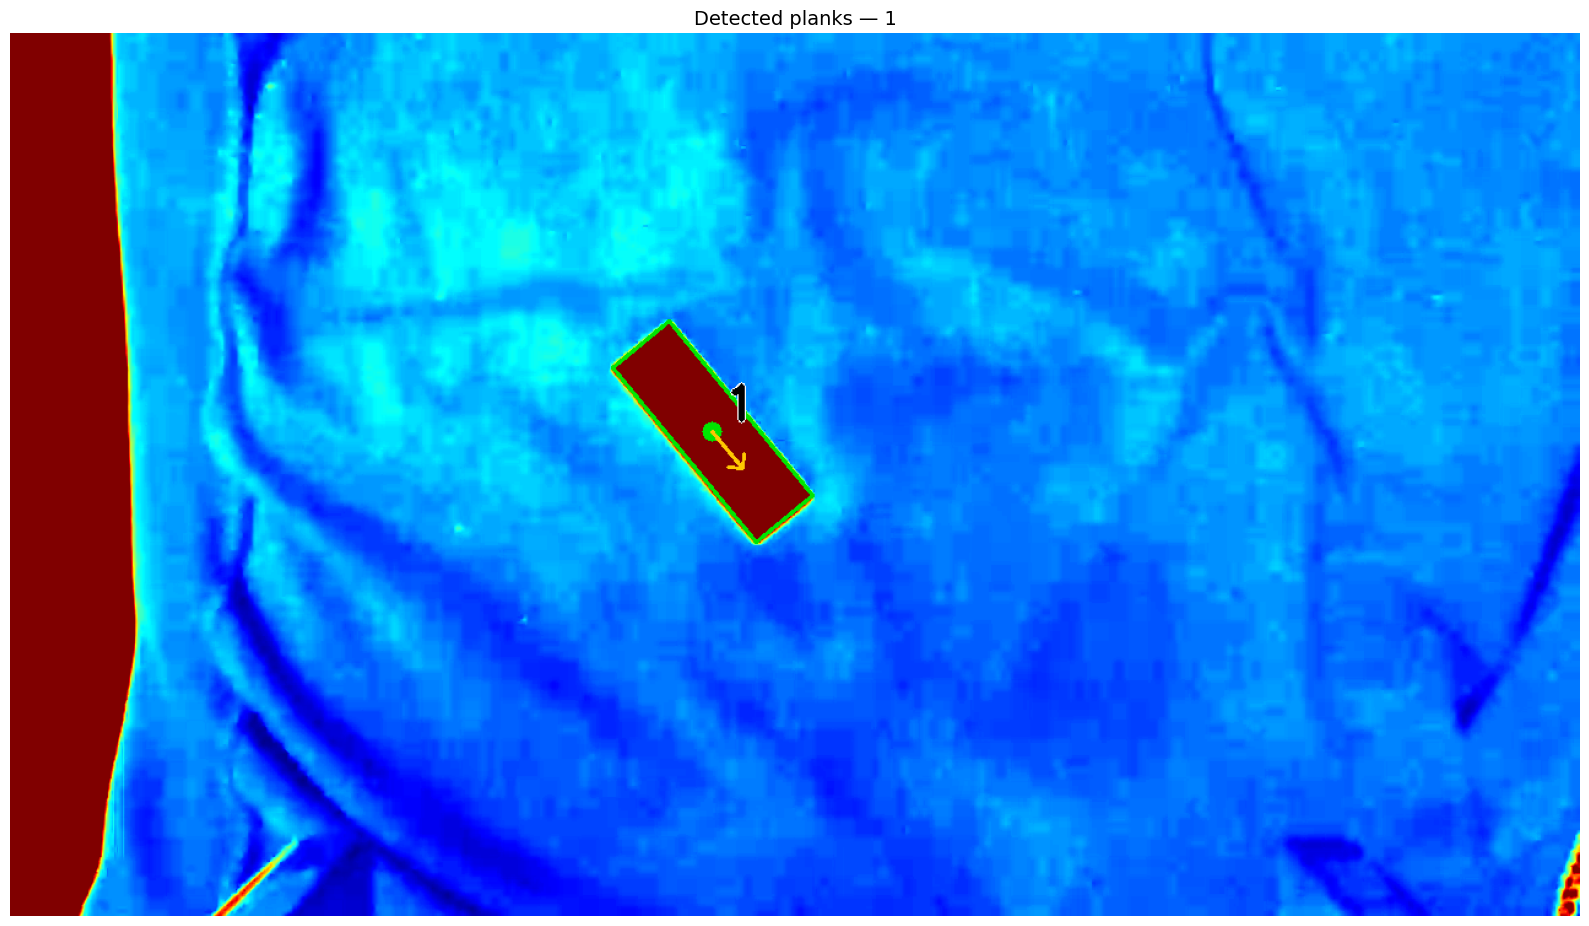

In [4]:
"""
Jenga Plank Detection
=====================
Detects flat-laying Jenga planks from two images of the same scene:
  - A raw grayscale image
  - A normalized color image derived from a depth sensor

For each detected plank, returns:
  - (cx, cy) : center position in pixels
  - angle    : orientation of the longest side relative to the x-axis (degrees)

Dependencies: opencv-python, numpy, matplotlib
"""

import cv2
import numpy as np
import matplotlib.pyplot as plt

def set_threshold(my_raw_img_path):
    my_raw_bgr = cv2.imread(my_raw_img_path)
    
    # mean color of the whole image, per channel
    col_avg = my_raw_bgr.mean(axis=(0, 1))

    # fraction of pixels whose average intensity is below the image average
    pixel_means = my_raw_bgr.mean(axis=2)
    count = np.count_nonzero(pixel_means < col_avg.mean())

    dark_pix_thersh=2*pixel_means.mean()*count/(my_raw_bgr.shape[0]*my_raw_bgr.shape[1])
    return dark_pix_thersh


# ── Scoring function ──────────────────────────────────────────────────────────

def score(c):
    """
    Score a candidate contour. Rewards large area, high solidity,
    and aspect ratio close to 3.0 (true Jenga plank ratio).
    """
    area, w, h, aspect, solidity = c[0], c[1], c[2], c[3], c[4]
    aspect_score = 1.0 - abs(aspect - 3.0) / 3.0
    return area * solidity * aspect_score


# ── Contour filtering ─────────────────────────────────────────────────────────

def _filter_contours(contours,
                     w_min=130, w_max=360,
                     h_min=35,  h_max=110,
                     aspect_min=2.2, aspect_max=5.5,
                     solidity_min=0.73,#0.65,
                     score_min=500):
    """
    Filter raw contours to keep only plank-shaped candidates.

    Parameters
    ----------
    w_min / w_max   : allowed range for the long dimension (pixels)
    h_min / h_max   : allowed range for the short dimension (pixels)
    aspect_min/max  : allowed range for w/h ratio
    solidity_min    : minimum contour solidity (area / convex hull area)
    score_min       : minimum score() value to keep a candidate
    """
    candidates = []
    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area < 1000:
            continue

        rect = cv2.minAreaRect(cnt)
        (cx, cy), (w, h), angle = rect
        # Ensure w is always the long side
        if w < h:
            w, h = h, w
            angle += 90

        if not (w_min < w < w_max and h_min < h < h_max):
            continue

        aspect = w / h if h > 0 else 0
        if not (aspect_min < aspect < aspect_max):
            continue

        hull      = cv2.convexHull(cnt)
        hull_area = cv2.contourArea(hull)
        solidity  = area / hull_area if hull_area > 0 else 0
        if solidity < solidity_min:
            continue

        c = (area, w, h, aspect, solidity, cx, cy, angle, rect)
        if score(c) < score_min:
            continue

        candidates.append(c)

    # Deduplicate: keep highest-score candidate within a 50px radius
    candidates.sort(key=lambda x: -score(x))
    seen     = []
    deduped  = []
    for c in candidates:
        cx, cy = c[5], c[6]
        if not any(abs(cx - s[0]) < 50 and abs(cy - s[1]) < 50 for s in seen):
            deduped.append(c)
            seen.append((cx, cy))

    return deduped


# ── Edge detection methods ────────────────────────────────────────────────────

def detect_canny(img_gray,
                 canny_low=15, canny_high=50,
                 clahe_clip=3.0,
                 close_k=7, dilate_iter=2,
                 **filter_kwargs):
    """
    Detect plank contours using Canny edge detection.

    Parameters
    ----------
    canny_low / canny_high : Canny hysteresis thresholds
    clahe_clip             : CLAHE contrast limit (higher = more contrast boost)
    close_k                : morphological closing kernel size (px)
    dilate_iter            : dilation iterations to bridge edge gaps
    **filter_kwargs        : forwarded to _filter_contours
    """
    clahe   = cv2.createCLAHE(clipLimit=clahe_clip, tileGridSize=(8, 8))
    img_eq  = clahe.apply(img_gray)
    blurred = cv2.GaussianBlur(img_eq, (5, 5), 0)
    edges   = cv2.Canny(blurred, canny_low, canny_high)

    close_kernel  = cv2.getStructuringElement(cv2.MORPH_RECT, (close_k, close_k))
    dilate_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    edges = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, close_kernel, iterations=2)
    edges = cv2.dilate(edges, dilate_kernel, iterations=dilate_iter)

    contours, _ = cv2.findContours(edges, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)
    return _filter_contours(contours, **filter_kwargs)


def detect_sobel(img_gray,
                 threshold=20,
                 clahe_clip=3.0,
                 close_k=9, dilate_k=3, dilate_iter=3,
                 **filter_kwargs):
    """
    Detect plank contours using Sobel gradient magnitude.
    More robust than Canny for low-contrast regions and touching planks.

    Parameters
    ----------
    threshold   : gradient magnitude threshold (0-255) — lower catches fainter edges
    clahe_clip  : CLAHE contrast limit
    close_k     : morphological closing kernel size — increase to bridge wider gaps
    dilate_k    : dilation kernel size
    dilate_iter : dilation iterations
    **filter_kwargs : forwarded to _filter_contours
    """
    clahe   = cv2.createCLAHE(clipLimit=clahe_clip, tileGridSize=(8, 8))
    img_eq  = clahe.apply(img_gray)
    blurred = cv2.GaussianBlur(img_eq, (5, 5), 0)

    sx  = cv2.Sobel(blurred, cv2.CV_64F, 1, 0, ksize=3)
    sy  = cv2.Sobel(blurred, cv2.CV_64F, 0, 1, ksize=3)
    mag = np.sqrt(sx**2 + sy**2)
    mag = np.uint8(255 * mag / mag.max())

    _, edges = cv2.threshold(mag, threshold, 255, cv2.THRESH_BINARY)

    close_kernel  = cv2.getStructuringElement(cv2.MORPH_RECT, (close_k,  close_k))
    dilate_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (dilate_k, dilate_k))
    edges = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, close_kernel, iterations=2)
    edges = cv2.dilate(edges, dilate_kernel, iterations=dilate_iter)

    contours, _ = cv2.findContours(edges, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)
    return _filter_contours(contours, **filter_kwargs)


# ── Merge multiple result lists ───────────────────────────────────────────────

def merge_all(*result_lists, merge_radius=60):
    """
    Merge detections from multiple methods/images.
    Keeps the highest-scoring detection within merge_radius pixels.
    """
    combined = [c for r in result_lists for c in r]
    combined.sort(key=lambda x: -score(x))
    seen   = []
    merged = []
    for c in combined:
        cx, cy = c[5], c[6]
        if not any(abs(cx - s[0]) < merge_radius and abs(cy - s[1]) < merge_radius
                   for s in seen):
            merged.append(c)
            seen.append((cx, cy))
    merged.sort(key=score, reverse=True)
    return merged


# ── Visualisation ─────────────────────────────────────────────────────────────

# Pixels with grayscale value strictly below this are considered "dark".
# Tune this constant to adjust the dark-pixel detection sensitivity.
#DARK_PIXEL_THRESHOLD = 30  # range 0–255
#DARK_PIXEL_THRESHOLD = 10  # range 0–255


def _dark_pixel_ratio(img_gray, rect):
    """
    Return the fraction of pixels inside the oriented bounding box (rect)
    that are darker than DARK_PIXEL_THRESHOLD.

    Strategy: warp the rotated patch to an axis-aligned rectangle, then
    threshold.  Uses the same rect produced by cv2.minAreaRect.
    """
    (cx, cy), (bw, bh), angle = rect

    # Ensure bw >= bh (long side first) — same convention as _filter_contours
    if bw < bh:
        bw, bh = bh, bw
        angle += 90

    bw, bh = max(1, int(bw)), max(1, int(bh))

    # Build the rotation matrix that straightens the box
    M = cv2.getRotationMatrix2D((cx, cy), angle, 1.0)

    # Rotate the whole grayscale image, then crop the axis-aligned patch
    rotated = cv2.warpAffine(
        img_gray, M,
        (img_gray.shape[1], img_gray.shape[0]),
        flags=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_REPLICATE,
    )

    x0 = max(0, int(cx - bw / 2))
    y0 = max(0, int(cy - bh / 2))
    x1 = min(rotated.shape[1], x0 + bw)
    y1 = min(rotated.shape[0], y0 + bh)

    patch = rotated[y0:y1, x0:x1]
    if patch.size == 0:
        return 0.0

    dark_pixels  = np.count_nonzero(patch < DARK_PIXEL_THRESHOLD)
    return dark_pixels / patch.size


def draw_detections(img_bgr, results, img_gray=None, arrow_length=40):
    """
    Draw oriented bounding boxes, center dots, direction arrows, and labels
    on a copy of img_bgr. Returns the annotated BGR image.

    Parameters
    ----------
    img_bgr     : BGR image to annotate (typically the color/depth image)
    results     : list of candidate tuples from _filter_contours / merge_all
    img_gray    : raw grayscale image used to compute dark-pixel ratio.
                  If None the ratio overlay is skipped.
    arrow_length: length of the orientation arrow in pixels
    """
    vis = img_bgr.copy()
    iw  = vis.shape[1]
    fs  = max(0.8, iw / 1000)
    th  = max(2,   iw // 500)

    for i, (area, w, h, aspect, solidity, cx, cy, angle, rect) in enumerate(results):

        box = cv2.boxPoints(rect).astype(np.int32)
        cv2.drawContours(vis, [box], 0, (0, 230, 0), th)
        cv2.circle(vis, (int(cx), int(cy)), 8, (0, 230, 0), -1)

        # Direction arrow along the long axis
        rad    = np.radians(angle)
        dx, dy = int(arrow_length * np.cos(rad)), int(arrow_length * np.sin(rad))
        cv2.arrowedLine(vis,
                        (int(cx), int(cy)),
                        (int(cx) + dx, int(cy) + dy),
                        (0, 200, 255), th, tipLength=0.3)

        # ── Labels (two lines) ────────────────────────────────────────────
        lx, ly = int(cx) + 10, int(cy) - 10
        """
        line_gap = int(fs * 28)  # vertical spacing between the two lines
        sol_label = f"sol:{solidity:.2f}"
        cv2.putText(vis, sol_label, (lx, ly),
                    cv2.FONT_HERSHEY_SIMPLEX, fs, (255, 255, 255), th + 4)
        cv2.putText(vis, sol_label, (lx, ly),
                    cv2.FONT_HERSHEY_SIMPLEX, fs, (0,   0,   0),   th + 1)
        
        if img_gray is not None:
            dark_ratio = _dark_pixel_ratio(img_gray, rect)
            drk_label  = f"drk:{dark_ratio:.2f}"
            cv2.putText(vis, drk_label, (lx, ly + line_gap),
                        cv2.FONT_HERSHEY_SIMPLEX, fs, (255, 255, 255), th + 4)
            cv2.putText(vis, drk_label, (lx, ly + line_gap),
                        cv2.FONT_HERSHEY_SIMPLEX, fs, (0,   0,   0),   th + 1)
        """
        # Number label: white outline + black text
        label  = str(i + 1)
        cv2.putText(vis, label, (lx, ly), cv2.FONT_HERSHEY_SIMPLEX, fs, (255, 255, 255), th + 4)
        cv2.putText(vis, label, (lx, ly), cv2.FONT_HERSHEY_SIMPLEX, fs, (0,   0,   0),   th + 1)


    return vis


def show_results(img_bgr, results, img_gray=None, title="Detected planks", figsize=(16, 10)):
    """Display annotated image inline in a Jupyter notebook."""
    vis = draw_detections(img_bgr, results, img_gray=img_gray)
    plt.figure(figsize=figsize)
    plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    plt.title(f"{title} — {len(results)} planks", fontsize=14)
    plt.axis('off')
    plt.tight_layout()
    plt.show()
    return vis


# ── Main pipeline ─────────────────────────────────────────────────────────────

def detect_planks(raw_image_path, color_image_path,
                  filter_params=None, show=True, save_path=None):
    """
    Full detection pipeline combining grayscale and depth/color images.

    Parameters
    ----------
    raw_image_path   : path to raw grayscale image
    color_image_path : path to normalized color (depth) image
    filter_params    : dict of kwargs forwarded to _filter_contours
                       (w_min, w_max, h_min, h_max, aspect_min, aspect_max,
                        solidity_min, score_min)
    show             : whether to display result in notebook
    save_path        : if provided, save annotated image here

    Returns
    -------
    results : list of (cx, cy, angle) tuples for each detected plank
    """
    if filter_params is None:
        filter_params = dict(
            w_min=130, w_max=360,
            h_min=35,  h_max=110,
            aspect_min=2.2, aspect_max=5.5,
            solidity_min=0.73,#0.65,
            score_min=500,
        )

    # Load images
    raw_bgr  = cv2.imread(raw_image_path)
    col_bgr  = cv2.imread(color_image_path)
    raw_gray = cv2.cvtColor(raw_bgr, cv2.COLOR_BGR2GRAY)

    # Extract hue channel from depth/color image (encodes depth as hue)
    hsv = cv2.cvtColor(col_bgr, cv2.COLOR_BGR2HSV)
    hue = hsv[:, :, 0]
    # Shift hue to avoid wrap-around artefacts near 0°/179°
    hue_shifted = np.clip(
        np.where(hue < 90, hue.astype(np.int16) + 180, hue.astype(np.int16)),
        0, 255
    ).astype(np.uint8)

    # Run 6 detection variants and merge
    r1 = detect_canny(raw_gray,    canny_low=15, canny_high=50, clahe_clip=3.0,
                      close_k=7,  dilate_iter=2, **filter_params)
    r2 = detect_canny(hue_shifted, canny_low=8,  canny_high=30, clahe_clip=2.0,
                      close_k=7,  dilate_iter=2, **filter_params)
    r3 = detect_sobel(raw_gray,    threshold=20, clahe_clip=3.0,
                      close_k=9,  dilate_k=3, dilate_iter=3, **filter_params)
    r4 = detect_sobel(hue_shifted, threshold=15, clahe_clip=2.0,
                      close_k=9,  dilate_k=3, dilate_iter=3, **filter_params)
    # Aggressive closing variants — best for touching/overlapping planks
    r5 = detect_sobel(raw_gray,    threshold=15, clahe_clip=4.0,
                      close_k=13, dilate_k=5, dilate_iter=4, **filter_params)
    r6 = detect_sobel(hue_shifted, threshold=10, clahe_clip=4.0,
                      close_k=13, dilate_k=5, dilate_iter=4, **filter_params)

    all_detections = merge_all(r1, r2, r3, r4, r5, r6)

    # Discard detections whose dark-pixel ratio exceeds the threshold.
    # Tune DARK_RATIO_MAX to adjust how much dark content is tolerated.
    DARK_RATIO_MAX = 0.8
    all_detections = [
        c for c in all_detections
        if _dark_pixel_ratio(raw_gray, c[8]) < DARK_RATIO_MAX
    ]

    # Return as simple (cx, cy, angle) tuples
    results = [(c[5], c[6], c[7]) for c in all_detections]

    if show or save_path:
        vis = draw_detections(col_bgr, all_detections, img_gray=raw_gray)
        if show:
            plt.figure(figsize=(16, 10))
            plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
            plt.title(f"Detected planks — {len(results)}", fontsize=14)
            plt.axis('off')
            plt.tight_layout()
            plt.show()
        if save_path:
            cv2.imwrite(save_path, vis)
            print(f"Saved to {save_path}")
    """
    print(f"Detected {len(results)} planks")
    for i, (cx, cy, angle) in enumerate(results):
        print(f"  Plank {i+1:>2}: cx={cx:>6.1f}  cy={cy:>6.1f}  angle={angle:>7.2f}°")
    """
    return results


# ── Example usage ─────────────────────────────────────────────────────────────

results = detect_planks(
    raw_image_path   = "images_from_tests\\false_positive\\rawImage1.png",
    color_image_path = "images_from_tests\\false_positive\\ColourImage1.png",
    #save_path        = "detected_planks.png",
)